# Step 7 — Final Visualization Integration
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen

## Objective
Produce a **consolidated set of publication-quality figures** that tell the full analytical story of the project across all pipeline steps. These figures are designed for direct use in the **project report** and **final presentation**.

**Structure:**
- Figure 1 — Corpus Overview (Step 1 summary)
- Figure 2 — POS Profile by Register (Step 2)
- Figure 3 — Domain Vocabulary Coverage (Step 3)
- Figure 4 — TF-IDF Divergence (Step 4)
- Figure 5 — Cosine Similarity (Step 5)
- Figure 6 — Classification Results + Hypothesis Summary (Step 6)
- Figure 7 — **Master Dashboard**: all hypotheses in one figure

**Input files:** all outputs from Steps 1–6  
**Output:** individual PNG figures + `figures/` folder + `master_dashboard.png`

## 1. Imports, Setup and Style

In [1]:
import pandas as pd
import numpy as np
import json
import os
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
COLORS       = ["#2E75B6", "#E67E22", "#27AE60"]   # institutional / popular / critical
REG_ORDER    = ["institutional", "popular_media", "critical_media"]
REG_LABELS   = ["Institutional", "Popular Media", "Critical Media"]

plt.rcParams.update({
    "font.family":    "serif",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi":     150,
})

# Output folder
os.makedirs("figures", exist_ok=True)
print("Setup complete. Output folder: ./figures/")

Setup complete. Output folder: ./figures/


## 2. Load All Pipeline Outputs

In [2]:
# Step 1 output
df_pre = pd.read_csv("corpus_preprocessed.csv")

# Step 2 output
df_pos = pd.read_csv("corpus_pos.csv")

# Step 3 output
df_dom = pd.read_csv("corpus_domain.csv")
with open("domain_dictionary.json", "r", encoding="utf-8") as f:
    domain_dict = json.load(f)

# Step 4 outputs
tfidf_matrix = sp.load_npz("tfidf_matrix.npz")
meta         = pd.read_csv("corpus_tfidf_meta.csv")
profiles_df  = pd.read_csv("tfidf_profiles_by_register.csv", index_col=0)
with open("tfidf_feature_names.json", "r", encoding="utf-8") as f:
    feature_names = np.array(json.load(f))

# Step 5 output
sim_results = pd.read_csv("cosine_similarity_results.csv")

# Step 6 outputs
clf_results = pd.read_csv("classification_results.csv")

print("All pipeline outputs loaded successfully.")
print(f"  Preprocessed corpus : {df_pre.shape}")
print(f"  POS corpus          : {df_pos.shape}")
print(f"  Domain corpus       : {df_dom.shape}")
print(f"  TF-IDF matrix       : {tfidf_matrix.shape}")
print(f"  Similarity results  : {sim_results.shape}")
print(f"  Classification res  : {clf_results.shape}")

All pipeline outputs loaded successfully.
  Preprocessed corpus : (180, 7)
  POS corpus          : (180, 20)
  Domain corpus       : (180, 29)
  TF-IDF matrix       : (180, 171)
  Similarity results  : (180, 11)
  Classification res  : (36, 12)


## 3. Refit Classifier (for coefficient plots)
We refit here using the same split to recover `clf.coef_` for Figure 6.

In [3]:
X = tfidf_matrix
y = meta["label"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, meta.index, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

clf = LogisticRegression(
    multi_class="multinomial", solver="lbfgs",
    C=1.0, max_iter=1000, random_state=RANDOM_STATE
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
baseline = 1 / 3

print(f"Classifier refit — Test accuracy: {accuracy:.4f}")

Classifier refit — Test accuracy: 0.7500


## 4. Figure 1 — Corpus Overview

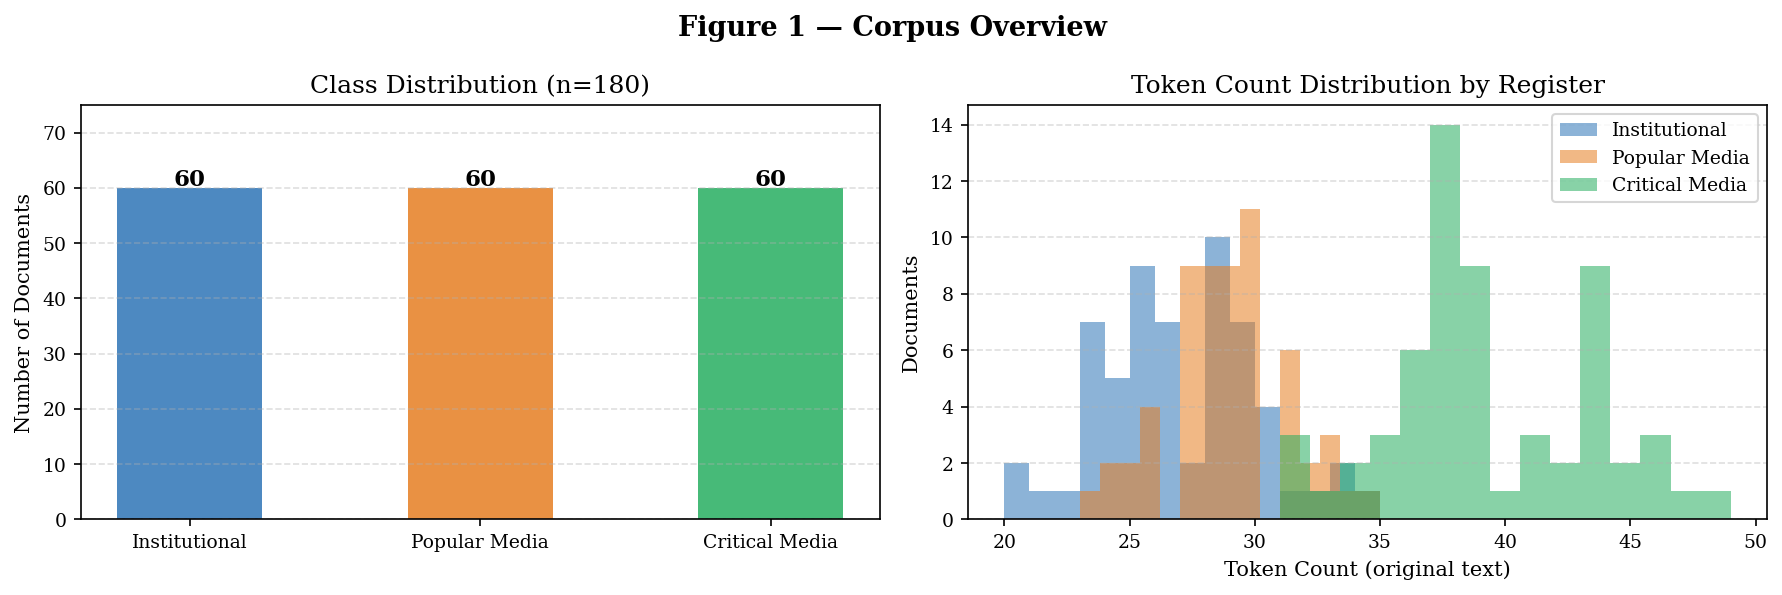

Saved: figures/fig1_corpus_overview.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4a: Class distribution
counts = df_pre["register"].value_counts().reindex(REG_ORDER)
axes[0].bar(REG_LABELS, counts.values, color=COLORS, alpha=0.85, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 75)
axes[0].set_ylabel("Number of Documents")
axes[0].set_title("Class Distribution (n=180)")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# 4b: Token count distribution
for reg, label, color in zip(REG_ORDER, REG_LABELS, COLORS):
    subset = df_pre[df_pre["register"] == reg]["token_count_original"]
    axes[1].hist(subset, bins=15, alpha=0.55, color=color, label=label)
axes[1].set_xlabel("Token Count (original text)")
axes[1].set_ylabel("Documents")
axes[1].set_title("Token Count Distribution by Register")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Figure 1 — Corpus Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig1_corpus_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig1_corpus_overview.png")

## 5. Figure 2 — POS Profile by Register

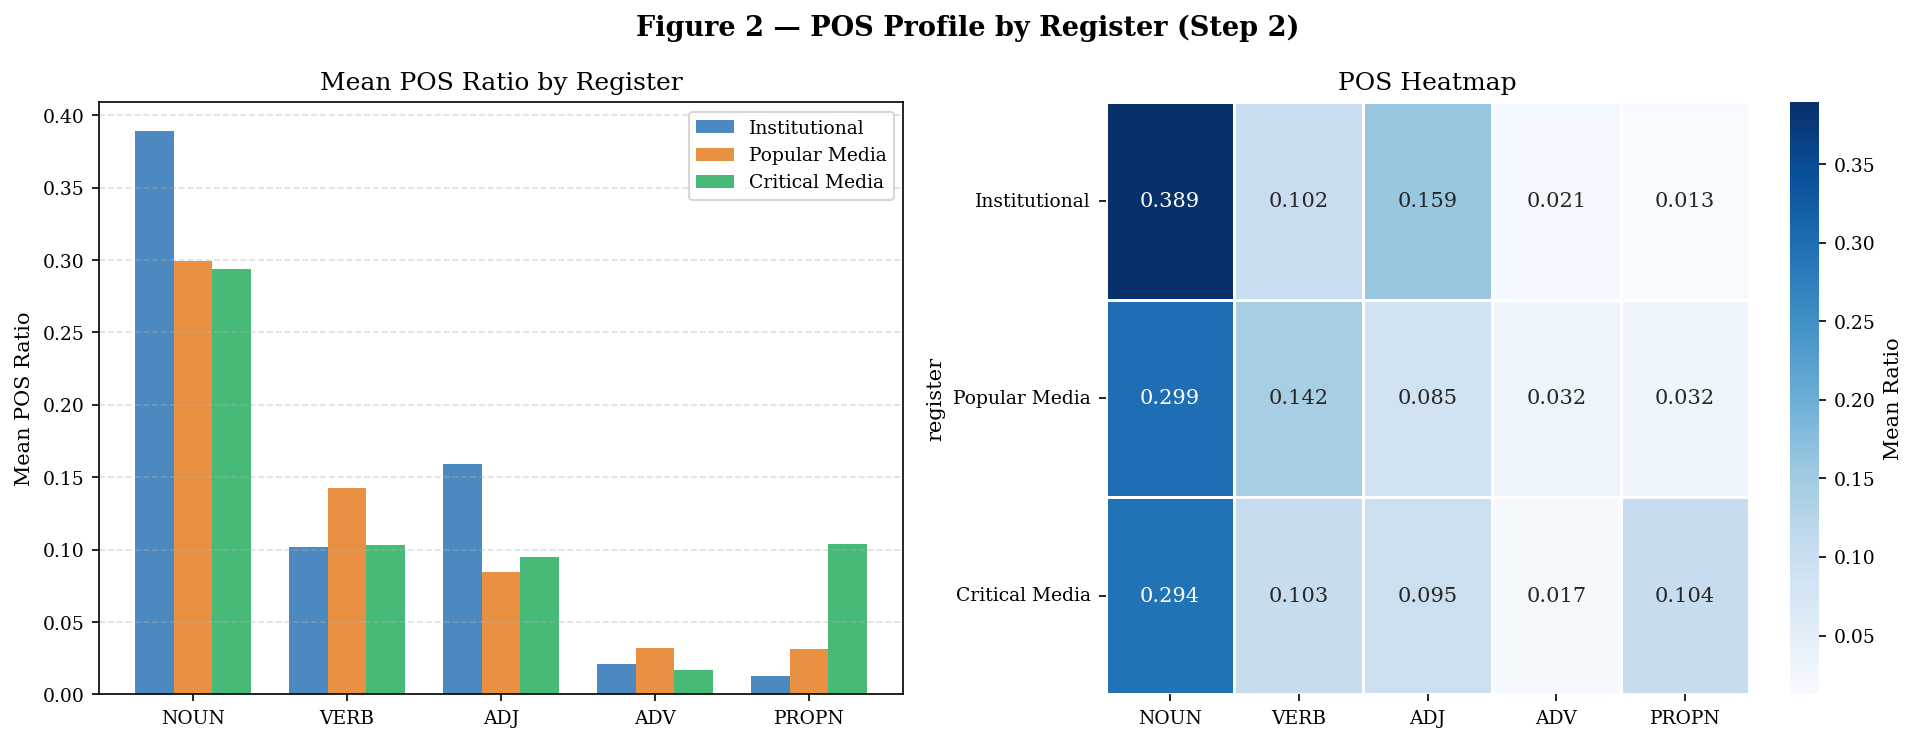

Saved: figures/fig2_pos_profile.png


In [5]:
TARGET_POS  = ["NOUN", "VERB", "ADJ", "ADV", "PROPN"]
ratio_cols  = [f"ratio_{p.lower()}" for p in TARGET_POS]
pos_by_reg  = df_pos.groupby("register")[ratio_cols].mean().round(4)
pos_by_reg.columns = TARGET_POS
pos_plot    = pos_by_reg.loc[REG_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar
x, width = np.arange(len(TARGET_POS)), 0.25
for i, (reg, label, color) in enumerate(zip(REG_ORDER, REG_LABELS, COLORS)):
    axes[0].bar(x + i * width, pos_plot.loc[reg].values,
                width, label=label, color=color, alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(TARGET_POS)
axes[0].set_ylabel("Mean POS Ratio")
axes[0].set_title("Mean POS Ratio by Register")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Heatmap
sns.heatmap(pos_plot, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, ax=axes[1], cbar_kws={"label": "Mean Ratio"})
axes[1].set_yticklabels(REG_LABELS, rotation=0)
axes[1].set_title("POS Heatmap")

plt.suptitle("Figure 2 — POS Profile by Register (Step 2)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig2_pos_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig2_pos_profile.png")

## 6. Figure 3 — Domain Vocabulary Coverage

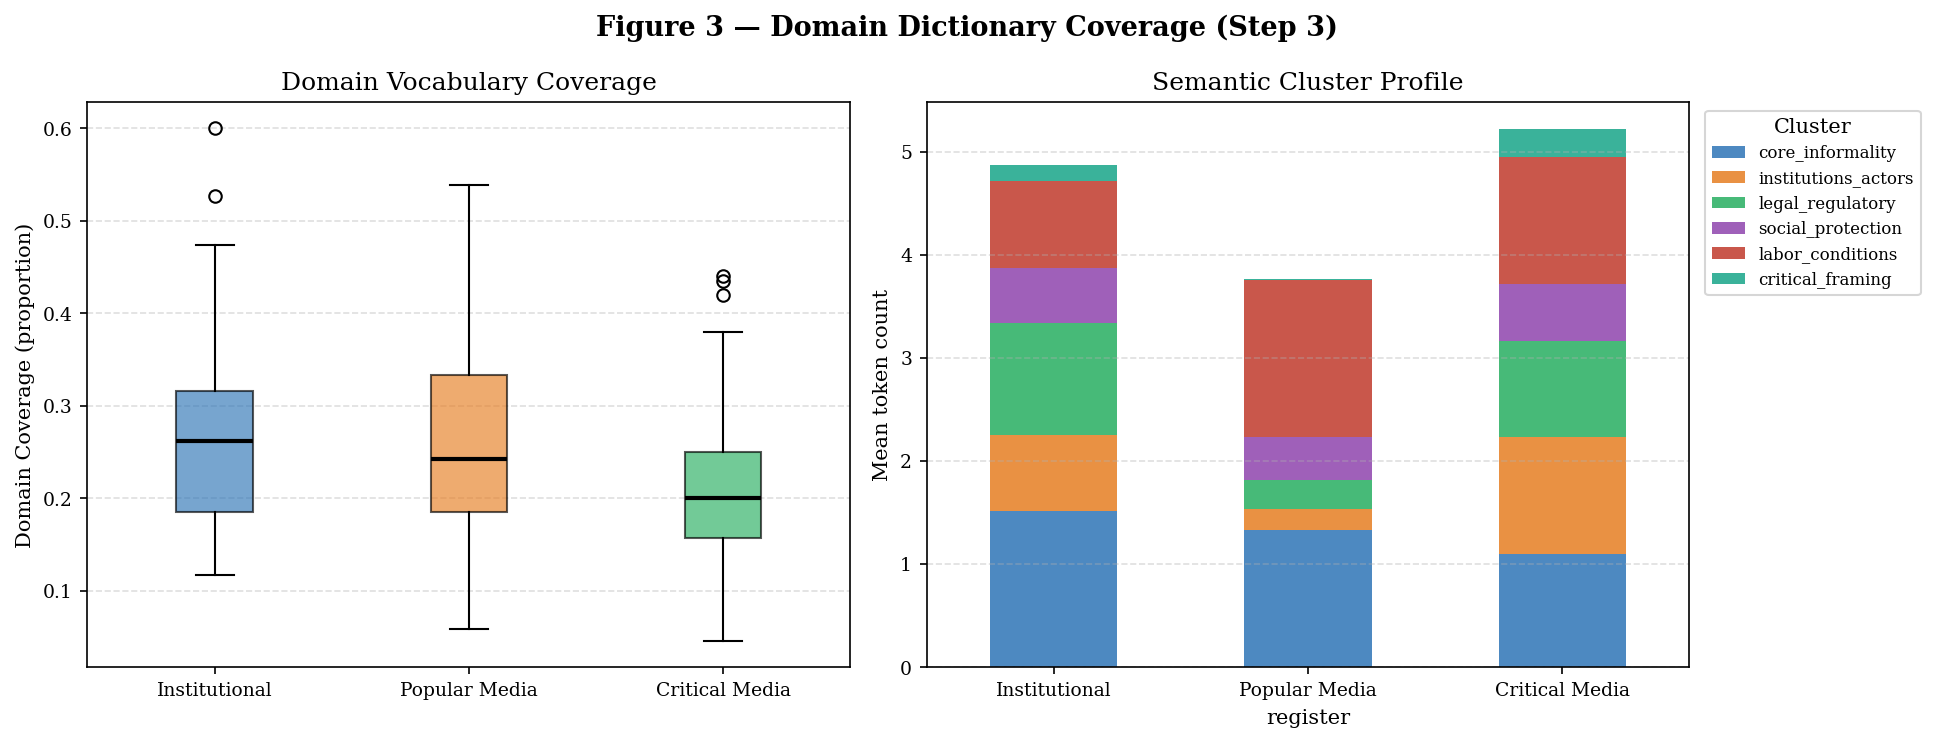

Saved: figures/fig3_domain_coverage.png


In [6]:
cluster_cols = list(domain_dict.keys())
cluster_by_reg = df_dom.groupby("register")[cluster_cols].mean().round(3)
cluster_plot   = cluster_by_reg.loc[REG_ORDER]

cluster_colors = ["#2E75B6","#E67E22","#27AE60","#8E44AD","#C0392B","#17A589"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coverage boxplot
data_by_reg = [df_dom[df_dom["register"] == r]["domain_coverage"].values for r in REG_ORDER]
bp = axes[0].boxplot(data_by_reg, labels=REG_LABELS, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.65)
axes[0].set_ylabel("Domain Coverage (proportion)")
axes[0].set_title("Domain Vocabulary Coverage")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Stacked cluster bars
cluster_plot.plot(kind="bar", stacked=True, ax=axes[1],
                  color=cluster_colors, alpha=0.85, width=0.5)
axes[1].set_xticklabels(REG_LABELS, rotation=0)
axes[1].set_ylabel("Mean token count")
axes[1].set_title("Semantic Cluster Profile")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Figure 3 — Domain Dictionary Coverage (Step 3)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig3_domain_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig3_domain_coverage.png")

## 7. Figure 4 — TF-IDF Divergence

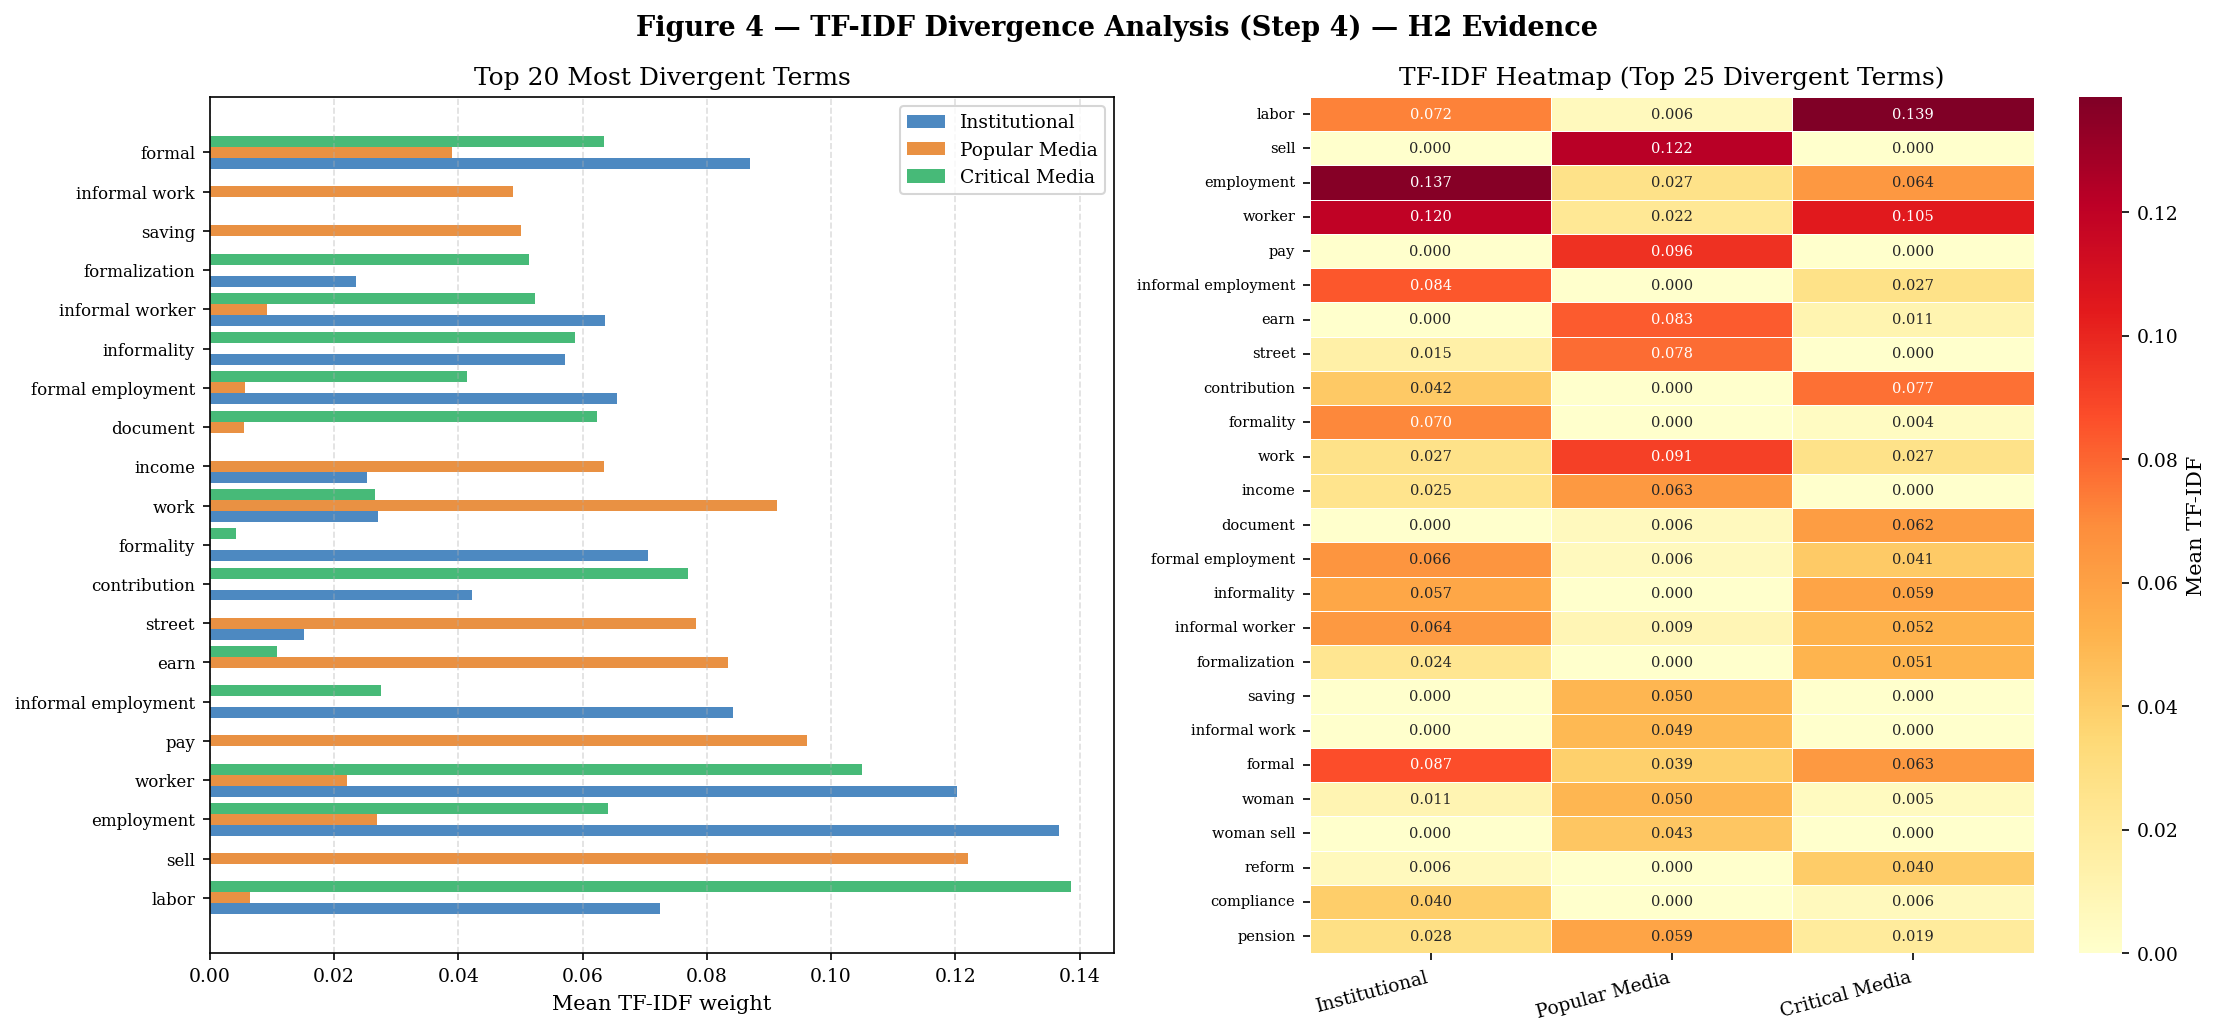

Saved: figures/fig4_tfidf_divergence.png


In [7]:
TOP_DIV = 20
div_data   = profiles_df.nlargest(TOP_DIV, "divergence")[REG_ORDER]
heat_data  = profiles_df.nlargest(25, "divergence")[REG_ORDER]
heat_data.columns = REG_LABELS

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Grouped bar — top divergent terms
x, width = np.arange(len(div_data)), 0.28
for i, (reg, label, color) in enumerate(zip(REG_ORDER, REG_LABELS, COLORS)):
    axes[0].barh(x + i * width, div_data[reg],
                 width, label=label, color=color, alpha=0.85)
axes[0].set_yticks(x + width)
axes[0].set_yticklabels(div_data.index, fontsize=8)
axes[0].set_xlabel("Mean TF-IDF weight")
axes[0].set_title(f"Top {TOP_DIV} Most Divergent Terms")
axes[0].legend()
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Heatmap
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.4, ax=axes[1], cbar_kws={"label": "Mean TF-IDF"},
            annot_kws={"size": 7})
axes[1].set_xticklabels(REG_LABELS, rotation=15, ha="right")
axes[1].set_title("TF-IDF Heatmap (Top 25 Divergent Terms)")
axes[1].tick_params(axis="y", labelsize=7)

plt.suptitle("Figure 4 — TF-IDF Divergence Analysis (Step 4) — H2 Evidence",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig4_tfidf_divergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig4_tfidf_divergence.png")

## 8. Figure 5 — Cosine Similarity

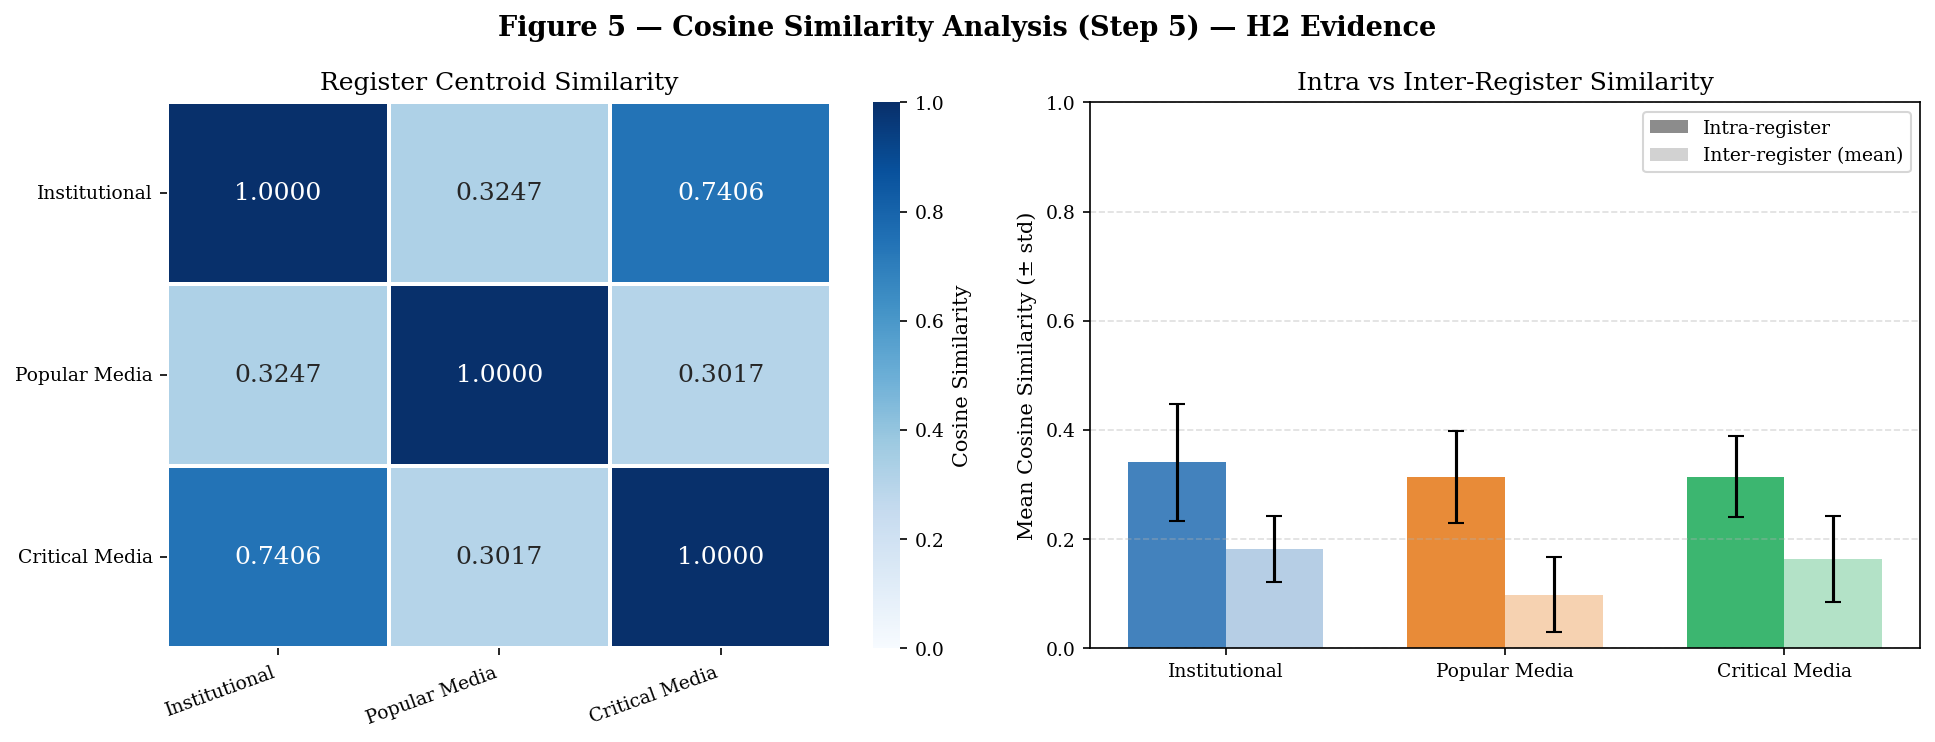

Saved: figures/fig5_cosine_similarity.png


In [8]:
tfidf_dense = tfidf_matrix.toarray()
centroids   = {r: tfidf_dense[meta["register"] == r].mean(axis=0, keepdims=True)
               for r in REG_ORDER}
centroid_mat = np.vstack([centroids[r] for r in REG_ORDER])
centroid_sim = cosine_similarity(centroid_mat)
centroid_sim_df = pd.DataFrame(centroid_sim, index=REG_LABELS, columns=REG_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Centroid heatmap
sns.heatmap(centroid_sim_df, annot=True, fmt=".4f", cmap="Blues",
            linewidths=1, ax=axes[0], vmin=0, vmax=1,
            cbar_kws={"label": "Cosine Similarity"},
            annot_kws={"size": 12})
axes[0].set_xticklabels(REG_LABELS, rotation=20, ha="right")
axes[0].set_yticklabels(REG_LABELS, rotation=0)
axes[0].set_title("Register Centroid Similarity")

# Intra vs inter bar chart
x = np.arange(len(REG_ORDER))
width = 0.35
for i, (reg, label, color) in enumerate(zip(REG_ORDER, REG_LABELS, COLORS)):
    subset = sim_results[sim_results["register"] == reg]
    axes[1].bar(i - width/2, subset["sim_intra"].mean(), width,
                color=color, alpha=0.9,
                yerr=subset["sim_intra"].std(), capsize=4)
    axes[1].bar(i + width/2, subset["sim_inter"].mean(), width,
                color=color, alpha=0.35,
                yerr=subset["sim_inter"].std(), capsize=4)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="grey", alpha=0.9,  label="Intra-register"),
    Patch(facecolor="grey", alpha=0.35, label="Inter-register (mean)")
])
axes[1].set_xticks(x)
axes[1].set_xticklabels(REG_LABELS)
axes[1].set_ylabel("Mean Cosine Similarity (± std)")
axes[1].set_ylim(0, 1)
axes[1].set_title("Intra vs Inter-Register Similarity")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Figure 5 — Cosine Similarity Analysis (Step 5) — H2 Evidence",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig5_cosine_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig5_cosine_similarity.png")

## 9. Figure 6 — Classification Results

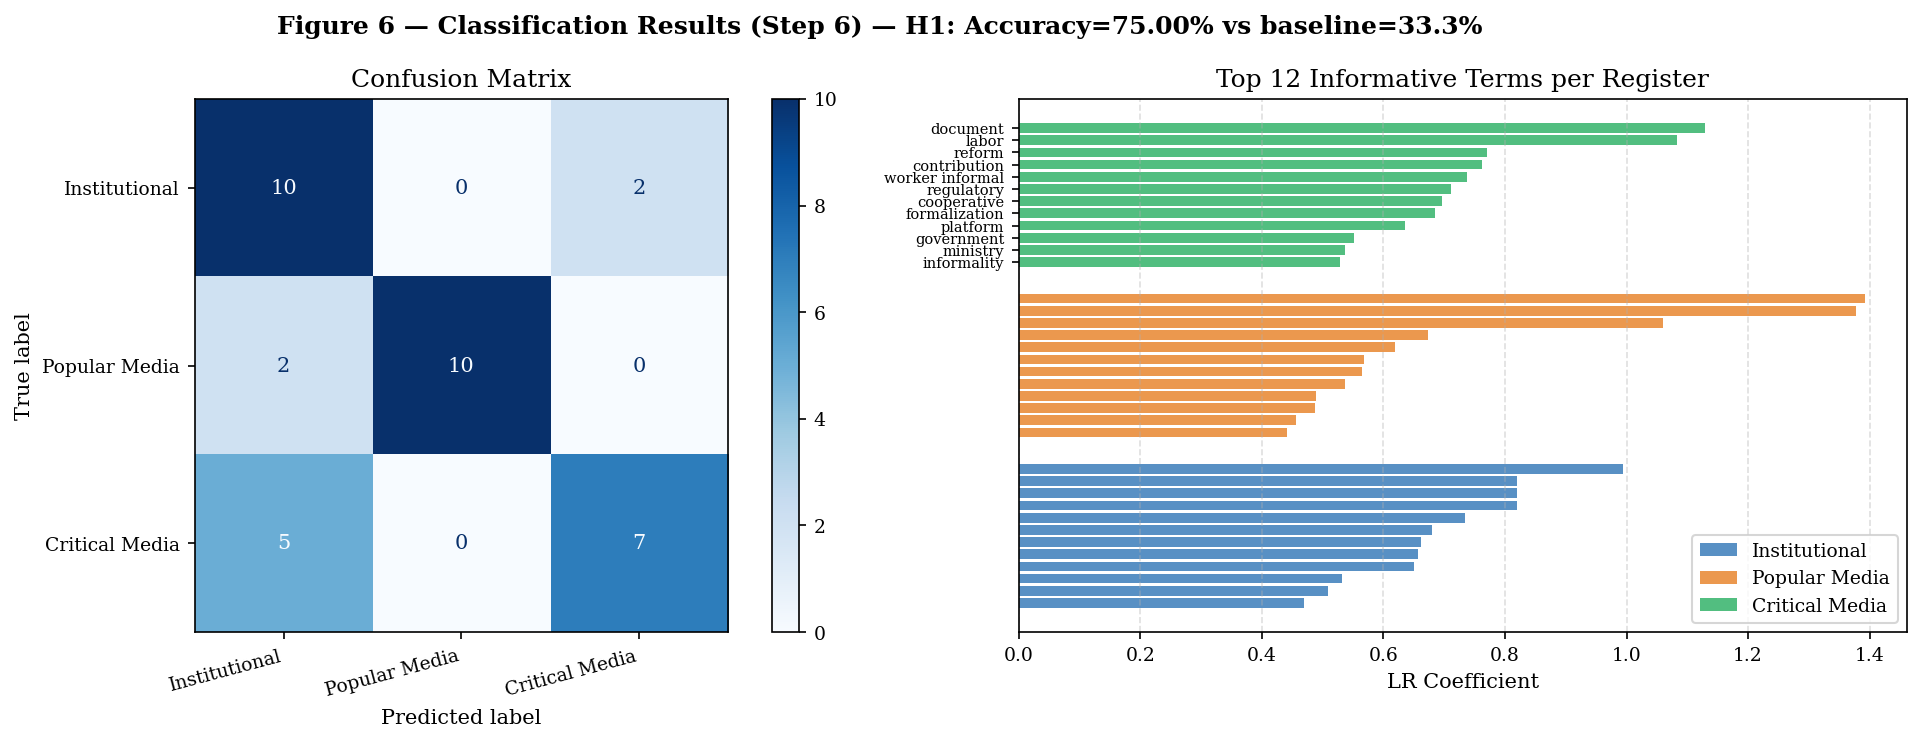

Saved: figures/fig6_classification.png


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=REG_LABELS)
disp.plot(ax=axes[0], colorbar=True, cmap="Blues")
axes[0].set_xticklabels(REG_LABELS, rotation=15, ha="right", fontsize=9)
axes[0].set_yticklabels(REG_LABELS, rotation=0, fontsize=9)
axes[0].set_title("Confusion Matrix")

# Feature importance
TOP_COEF = 12
for i, (label, color) in enumerate(zip(REG_LABELS, COLORS)):
    coefs   = clf.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_COEF:][::-1]
    top_terms = feature_names[top_idx]
    top_vals  = coefs[top_idx]
    y_pos = np.arange(TOP_COEF) + i * (TOP_COEF + 2)
    axes[1].barh(y_pos, top_vals[::-1], color=color, alpha=0.8, label=label)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(top_terms[::-1], fontsize=7)

axes[1].set_xlabel("LR Coefficient")
axes[1].set_title(f"Top {TOP_COEF} Informative Terms per Register")
axes[1].legend(loc="lower right")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    f"Figure 6 — Classification Results (Step 6) — H1: Accuracy={accuracy:.2%} vs baseline=33.3%",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("figures/fig6_classification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig6_classification.png")

## 10. Figure 7 — Master Dashboard

Single figure combining the six key panels for the final presentation slide.

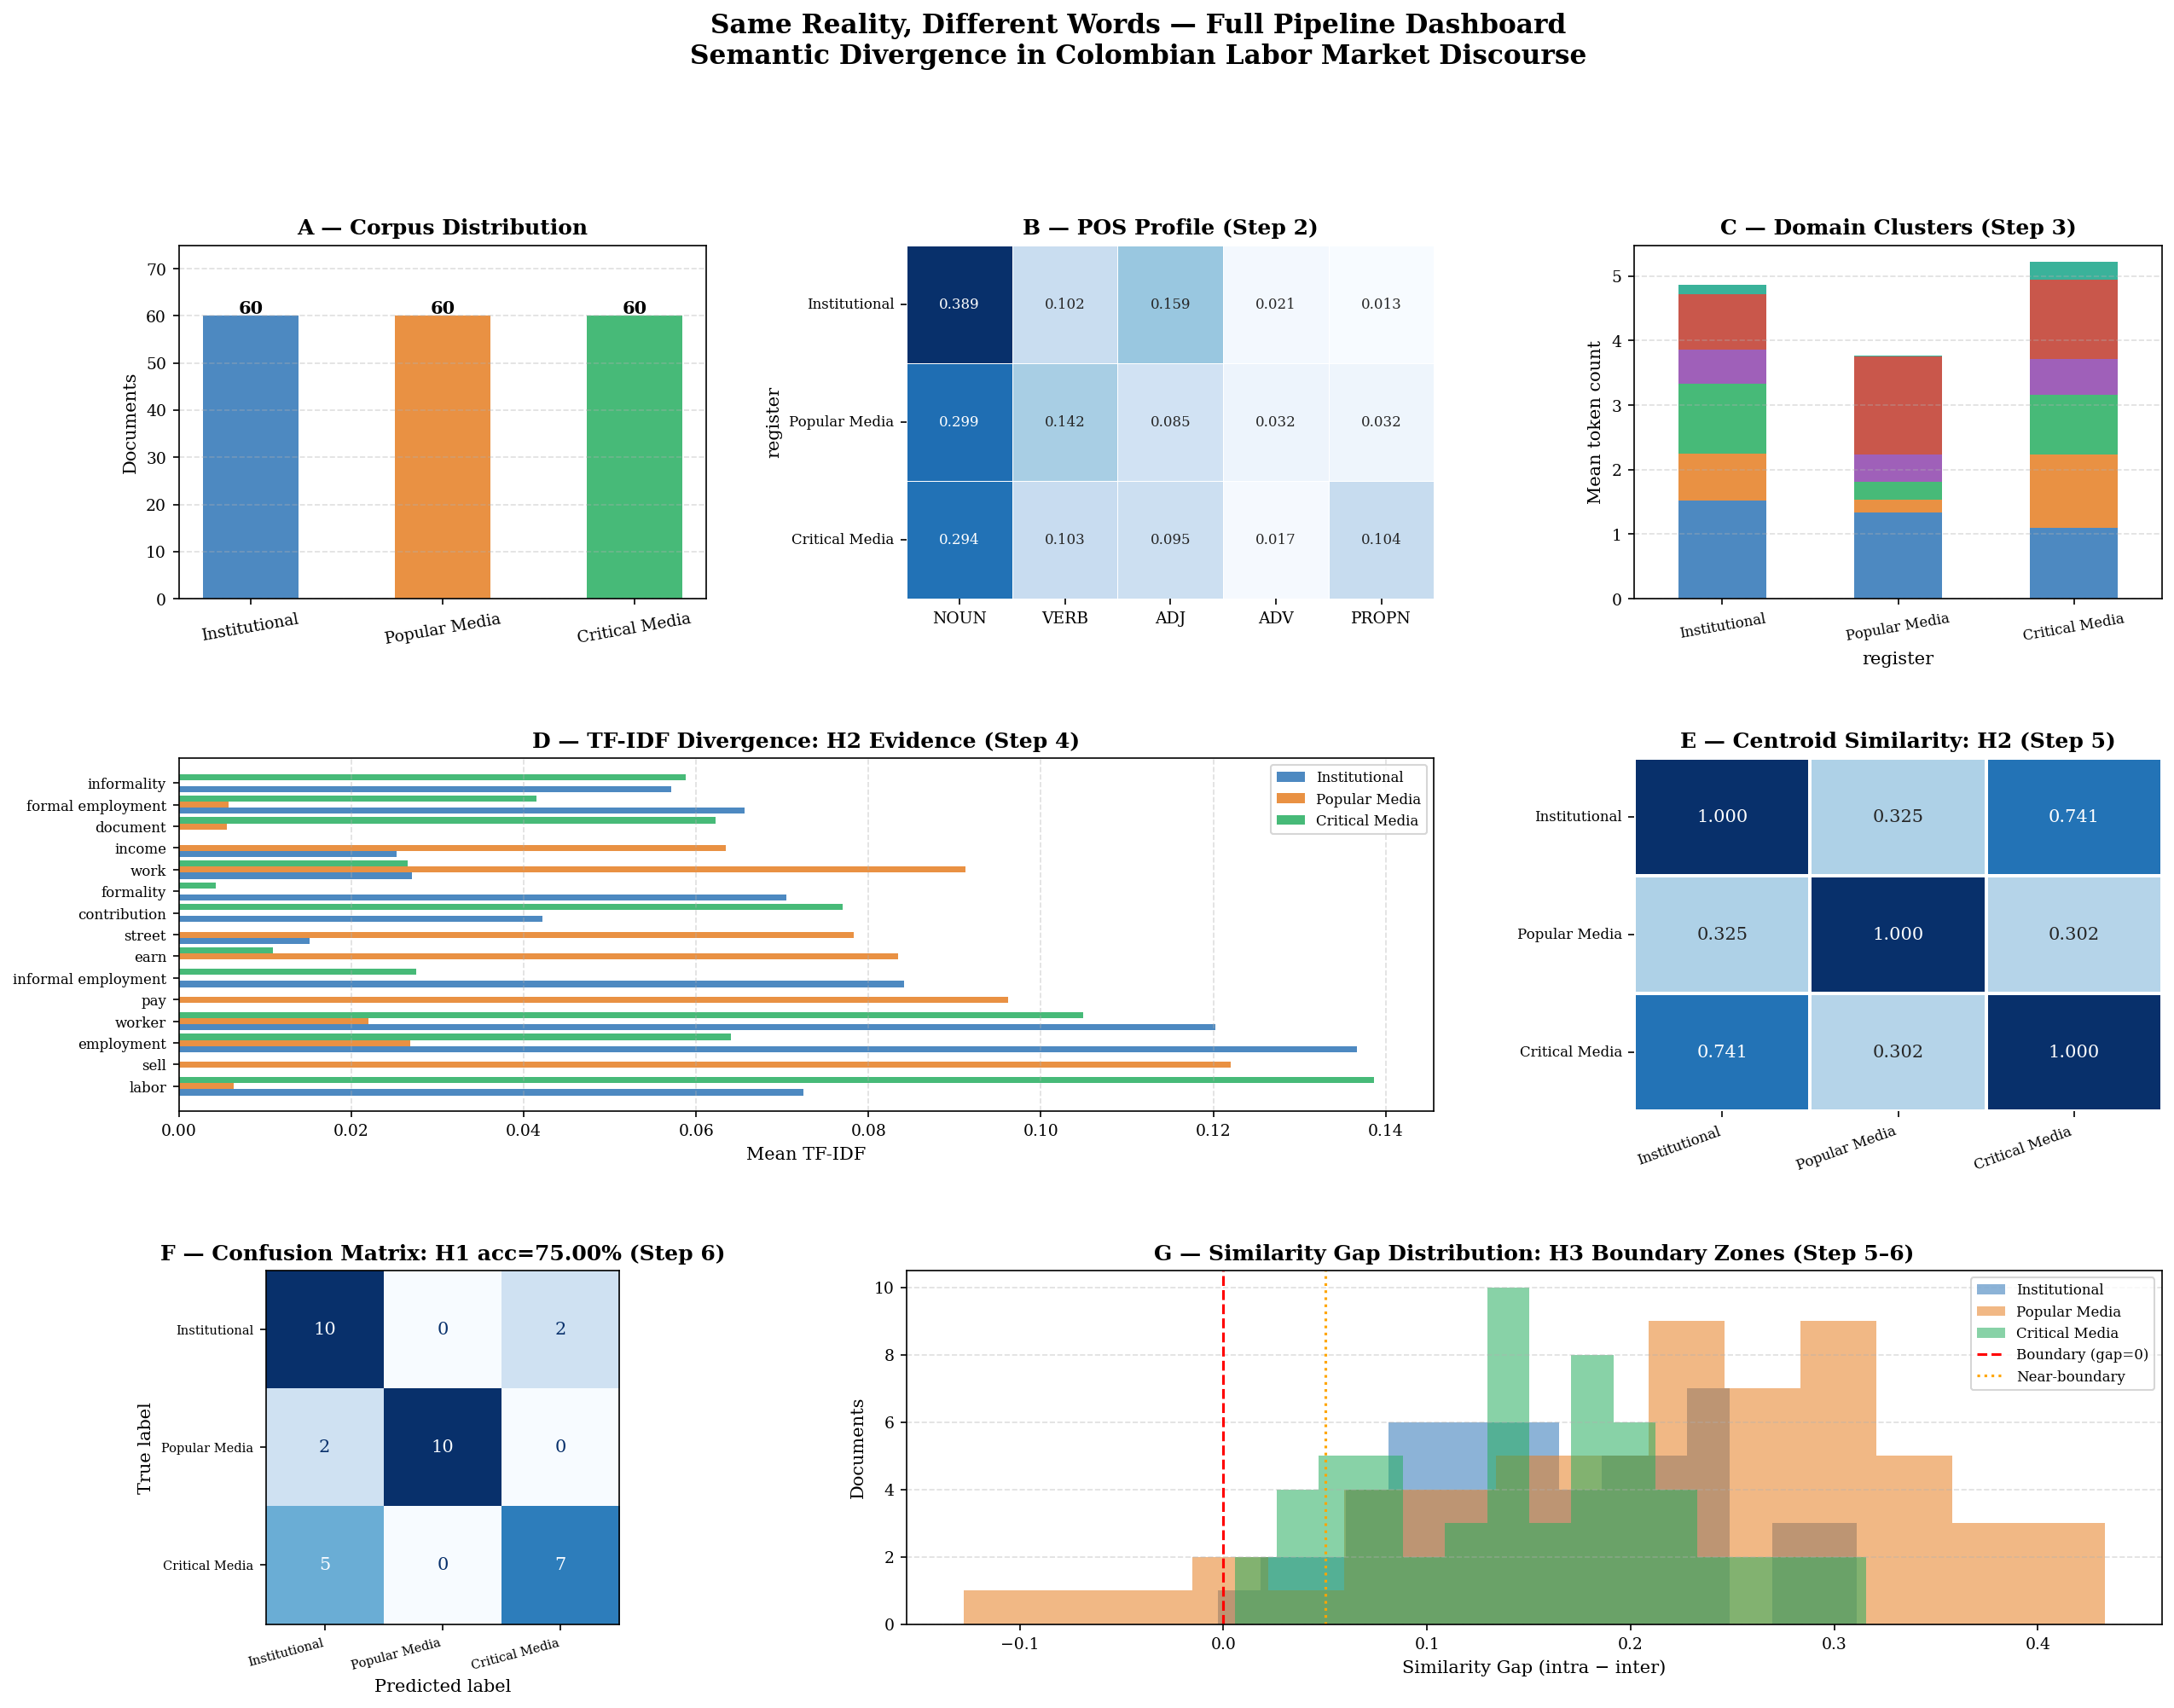

Saved: figures/fig7_master_dashboard.png


In [10]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel A: Class distribution ──────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
counts = df_pre["register"].value_counts().reindex(REG_ORDER)
ax_a.bar(REG_LABELS, counts.values, color=COLORS, alpha=0.85, width=0.5)
for i, v in enumerate(counts.values):
    ax_a.text(i, v + 0.5, str(v), ha="center", fontsize=10, fontweight="bold")
ax_a.set_ylim(0, 75)
ax_a.set_title("A — Corpus Distribution", fontweight="bold")
ax_a.set_ylabel("Documents")
ax_a.grid(axis="y", linestyle="--", alpha=0.4)
ax_a.tick_params(axis="x", rotation=10)

# ── Panel B: POS ratios heatmap ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sns.heatmap(pos_plot, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.4, ax=ax_b, cbar=False, annot_kws={"size": 8})
ax_b.set_yticklabels(REG_LABELS, rotation=0, fontsize=8)
ax_b.set_title("B — POS Profile (Step 2)", fontweight="bold")

# ── Panel C: Domain cluster profile ──────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
cluster_plot.plot(kind="bar", stacked=True, ax=ax_c,
                  color=cluster_colors, alpha=0.85, width=0.5, legend=False)
ax_c.set_xticklabels(REG_LABELS, rotation=10, fontsize=8)
ax_c.set_ylabel("Mean token count")
ax_c.set_title("C — Domain Clusters (Step 3)", fontweight="bold")
ax_c.grid(axis="y", linestyle="--", alpha=0.4)

# ── Panel D: TF-IDF top divergent terms ──────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0:2])
TOP_D = 15
div_d = profiles_df.nlargest(TOP_D, "divergence")[REG_ORDER]
x_d, w_d = np.arange(len(div_d)), 0.28
for i, (reg, label, color) in enumerate(zip(REG_ORDER, REG_LABELS, COLORS)):
    ax_d.barh(x_d + i * w_d, div_d[reg], w_d, label=label, color=color, alpha=0.85)
ax_d.set_yticks(x_d + w_d)
ax_d.set_yticklabels(div_d.index, fontsize=8)
ax_d.set_xlabel("Mean TF-IDF")
ax_d.set_title("D — TF-IDF Divergence: H2 Evidence (Step 4)", fontweight="bold")
ax_d.legend(fontsize=8)
ax_d.grid(axis="x", linestyle="--", alpha=0.4)

# ── Panel E: Centroid similarity heatmap ─────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
sns.heatmap(centroid_sim_df, annot=True, fmt=".3f", cmap="Blues",
            linewidths=1, ax=ax_e, vmin=0, vmax=1, cbar=False,
            annot_kws={"size": 10})
ax_e.set_xticklabels(REG_LABELS, rotation=20, ha="right", fontsize=8)
ax_e.set_yticklabels(REG_LABELS, rotation=0, fontsize=8)
ax_e.set_title("E — Centroid Similarity: H2 (Step 5)", fontweight="bold")

# ── Panel F: Confusion matrix ─────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 0])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=REG_LABELS)
disp2.plot(ax=ax_f, colorbar=False, cmap="Blues")
ax_f.set_xticklabels(REG_LABELS, rotation=15, ha="right", fontsize=7)
ax_f.set_yticklabels(REG_LABELS, rotation=0, fontsize=7)
ax_f.set_title(f"F — Confusion Matrix: H1 acc={accuracy:.2%} (Step 6)",
               fontweight="bold")

# ── Panel G: Similarity gap — H3 boundary ────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 1:3])
for reg, label, color in zip(REG_ORDER, REG_LABELS, COLORS):
    subset = sim_results[sim_results["register"] == reg]["sim_gap"]
    ax_g.hist(subset, bins=15, alpha=0.55, color=color, label=label)
ax_g.axvline(x=0,    color="red",    linestyle="--", linewidth=1.5, label="Boundary (gap=0)")
ax_g.axvline(x=0.05, color="orange", linestyle=":",  linewidth=1.5, label="Near-boundary")
ax_g.set_xlabel("Similarity Gap (intra − inter)")
ax_g.set_ylabel("Documents")
ax_g.set_title("G — Similarity Gap Distribution: H3 Boundary Zones (Step 5–6)",
               fontweight="bold")
ax_g.legend(fontsize=8)
ax_g.grid(axis="y", linestyle="--", alpha=0.4)

# ── Master title ──────────────────────────────────────────────────────────────
fig.suptitle(
    "Same Reality, Different Words — Full Pipeline Dashboard\n"
    "Semantic Divergence in Colombian Labor Market Discourse",
    fontsize=15, fontweight="bold", y=1.01
)

plt.savefig("figures/fig7_master_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig7_master_dashboard.png")

## 11. Figure Inventory

In [11]:
figures = {
    "fig1_corpus_overview.png"  : "Corpus distribution + token count — report Section: Methods",
    "fig2_pos_profile.png"      : "POS ratios by register — report Section: Results (Step 2)",
    "fig3_domain_coverage.png"  : "Domain vocabulary coverage + cluster profile — Results (Step 3)",
    "fig4_tfidf_divergence.png" : "TF-IDF divergence: H2 evidence — Results (Step 4)",
    "fig5_cosine_similarity.png": "Cosine similarity: H2 continued — Results (Step 5)",
    "fig6_classification.png"   : "Confusion matrix + LR coefficients: H1/H2 — Results (Step 6)",
    "fig7_master_dashboard.png" : "Master dashboard — Final presentation slide",
}

print("=== FIGURE INVENTORY ===")
for fname, desc in figures.items():
    path = f"figures/{fname}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists}  {fname}")
    print(f"       → {desc}")

print("\n=== PIPELINE COMPLETE ===")
print("All 7 steps executed. Outputs ready for report and presentation.")

=== FIGURE INVENTORY ===
  ✅  fig1_corpus_overview.png
       → Corpus distribution + token count — report Section: Methods
  ✅  fig2_pos_profile.png
       → POS ratios by register — report Section: Results (Step 2)
  ✅  fig3_domain_coverage.png
       → Domain vocabulary coverage + cluster profile — Results (Step 3)
  ✅  fig4_tfidf_divergence.png
       → TF-IDF divergence: H2 evidence — Results (Step 4)
  ✅  fig5_cosine_similarity.png
       → Cosine similarity: H2 continued — Results (Step 5)
  ✅  fig6_classification.png
       → Confusion matrix + LR coefficients: H1/H2 — Results (Step 6)
  ✅  fig7_master_dashboard.png
       → Master dashboard — Final presentation slide

=== PIPELINE COMPLETE ===
All 7 steps executed. Outputs ready for report and presentation.
